# 02 -- Real Cancer Drivers: Comparing Four Catalogs

Cancer driver genes are those whose mutation confers a selective growth advantage to tumor
cells. Multiple research groups have independently curated catalogs of such genes, each
applying different evidence thresholds and computational methods:

| Catalog | Short name | Description |
|---------|------------|-------------|
| Vogelstein *et al.* 2013 | **Vogelstein** | 138 curated high-confidence drivers |
| COSMIC Cancer Gene Census | **COSMIC_CGC** | ~580 genes from somatic mutation data |
| OncoKB | **OncoKB** | Precision oncology knowledge base (~1200 genes) |
| IntOGen | **IntOGen** | Computational pan-cancer drivers (~630 genes) |

This notebook answers:

- How much do the catalogs agree?
- Which genes appear in **all four** catalogs?
- Are the overlaps statistically significant?
- How can we customize the diagram for a manuscript?


In [1]:
import venn_diagram_lab as vdl

print(f'venn-diagram-lab {vdl.__version__}')

venn-diagram-lab 0.7.0


## Load the dataset

The sample `dataset_real_cancer_drivers_4` ships with the package. It encodes set membership as a 4-column TSV where each column represents one catalog and each row is a gene.

In [2]:
ds = vdl.load_sample('dataset_real_cancer_drivers_4')
print('Sets:', ds.set_names)

Sets: ['Vogelstein', 'COSMIC_CGC', 'OncoKB', 'IntOGen']


## Catalog sizes

Before comparing, check the raw size of each catalog. Large size differences affect all similarity metrics.

In [3]:
for name in ds.set_names:
    print(f'  {name:15s}: {len(ds.items[name]):4d} genes')

  Vogelstein     :  138 genes
  COSMIC_CGC     :  581 genes
  OncoKB         : 1231 genes
  IntOGen        :  633 genes


## Run the analysis

`vdl.analyze` picks the best-matching Venn model automatically (`model='auto'`). For 4 sets it selects the 4-set Edwards-Venn diagram.

In [4]:
result = vdl.analyze(ds, model='auto')
print('Model :', result.model)
print('Set sizes:', dict(result.set_sizes))

Model : venn-4-set
Set sizes: {'Vogelstein': 138, 'COSMIC_CGC': 581, 'OncoKB': 1231, 'IntOGen': 633}


## Default Venn diagram

The diagram renders inline in Jupyter via `_repr_svg_`. The counts shown in each region are the number of **exclusive** items (genes that belong to exactly that combination of sets).

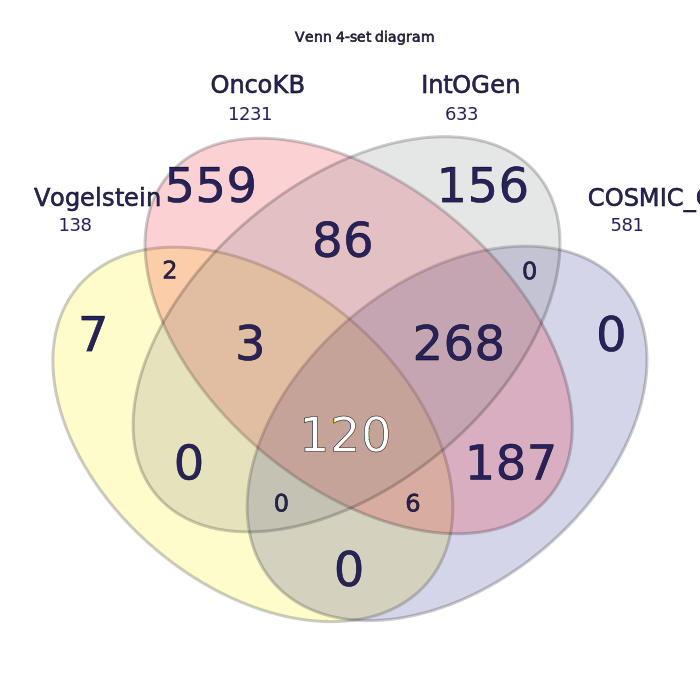

In [5]:
result.render_venn()

## The 'core' driver genes (intersection of all 4 catalogs)

Bitmask `0b1111` (= 15) selects the region belonging to **all four** sets simultaneously. `exclusive_items` are the genes found in every catalog.

In [6]:
ABCD = 0b1111  # all four sets
if ABCD in result.regions:
    core_genes = result.regions[ABCD].exclusive_items
    print(f'{len(core_genes)} genes appear in all 4 catalogs.')
    print('First 10:', list(core_genes)[:10])
else:
    print('No genes appear in all 4 catalogs simultaneously.')

120 genes appear in all 4 catalogs.
First 10: ['SETD2', 'TSC1', 'SMARCB1', 'KLF4', 'CARD11', 'GNA11', 'MYC', 'WT1', 'CTNNB1', 'SMAD4']


### Interpretation

These **core driver genes** represent the highest-confidence subset: every major catalog independently identified them as cancer drivers using different data sources and scoring methods. They are strong candidates for targeted therapy development and biomarker validation.

The large size of the COSMIC_CGC, OncoKB, and IntOGen catalogs relative to Vogelstein reflects the different scope of each resource -- Vogelstein deliberately curated a conservative high-confidence list, while the others cast a wider net.

## Pairwise Jaccard similarity

Jaccard(A, B) = |A & B| / |A | B|. Values range from 0 (no overlap) to 1 (identical).
The matrix is symmetric; diagonal entries are 1.

In [7]:
result.statistics.jaccard

,Vogelstein,COSMIC_CGC,OncoKB,IntOGen
Vogelstein,1.000000,0.212479,0.105816,0.189815
COSMIC_CGC,0.212479,1.000000,0.471974,0.469734
OncoKB,0.105816,0.471974,1.000000,0.343908
IntOGen,0.189815,0.469734,0.343908,1.000000


### Interpretation

COSMIC_CGC and OncoKB share the highest Jaccard (~0.47), reflecting that both are broad community databases updated with overlapping literature. Vogelstein has the lowest similarity to all others because it is the smallest and most conservative catalog.

## Pairwise Dice similarity

Dice(A, B) = 2|A ∩ B| / (|A| + |B|). Dice is always >= Jaccard for the same pair because it penalizes size differences less harshly.

In [8]:
result.statistics.dice

,Vogelstein,COSMIC_CGC,OncoKB,IntOGen
Vogelstein,1.000000,0.350487,0.191381,0.319066
COSMIC_CGC,0.350487,1.000000,0.641280,0.639209
OncoKB,0.191381,0.641280,1.000000,0.511803
IntOGen,0.319066,0.639209,0.511803,1.000000


## Hypergeometric over-representation

For each pair the hypergeometric test asks: *given the universe of all genes (~20,000), is the overlap larger than expected by chance?* Significant pairs (BH-adjusted p < 0.05) indicate genuine co-annotation.

In [9]:
result.statistics.hypergeometric

,set_a,set_b,intersection,expected,p_value,p_adjusted,significant,highly_significant
0,COSMIC_CGC,OncoKB,581,35.76055,0.000000e+00,0.000000e+00,True,True
1,COSMIC_CGC,IntOGen,388,18.38865,0.000000e+00,0.000000e+00,True,True
2,OncoKB,IntOGen,477,38.96115,0.000000e+00,0.000000e+00,True,True
3,Vogelstein,COSMIC_CGC,126,4.00890,6.751534e-184,1.012730e-183,True,True
4,Vogelstein,IntOGen,123,4.36770,4.613517e-171,5.536220e-171,True,True
5,Vogelstein,OncoKB,131,8.49390,3.131045e-151,3.131045e-151,True,True


### Discussion

All six pairs are overwhelmingly significant (BH-FDR p << 0.001), confirming that the catalog overlaps are not random against a ~20,000-gene background. Fold enrichments range from ~12x (OncoKB / IntOGen, the two largest catalogs, where the denominator effect dampens the ratio) up to ~31x (Vogelstein / COSMIC_CGC, where the small Vogelstein list overlaps almost completely with the larger CGC). Several large-vs-large pairs return p = 0.0 in double precision; the package's `p_adjusted` column applies BH-FDR but the correction is dwarfed by the raw effect sizes.

## Customize names and colors

Use `set_names` to apply publication-ready labels and `colors` to assign brand colors. The `title` argument sets the diagram heading.

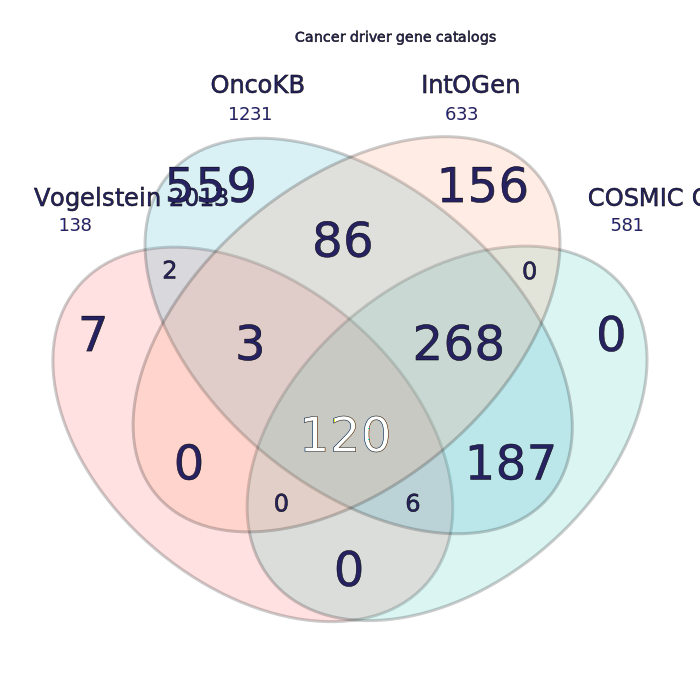

In [10]:
result.render_venn(
    set_names={
        'A': 'Vogelstein 2013',
        'B': 'COSMIC CGC',
        'C': 'OncoKB',
        'D': 'IntOGen',
    },
    colors={
        'A': '#FF6B6B',
        'B': '#4ECDC4',
        'C': '#45B7D1',
        'D': '#FFA07A',
    },
    title='Cancer driver gene catalogs',
)

## Export for a manuscript

`SvgImage.save(path, dpi=300)` produces publication-grade rasters. Pass a `.svg` path for lossless vector output (preferred for journal submissions) or `.png` / `.pdf` for raster/PDF output.

In [11]:
from pathlib import Path

img = result.render_venn(
    set_names={
        'A': 'Vogelstein 2013',
        'B': 'COSMIC CGC',
        'C': 'OncoKB',
        'D': 'IntOGen',
    },
    colors={
        'A': '#FF6B6B',
        'B': '#4ECDC4',
        'C': '#45B7D1',
        'D': '#FFA07A',
    },
    title='Cancer driver gene catalogs',
)

out_png = Path('/tmp/cancer_drivers_venn.png')
out_svg = Path('/tmp/cancer_drivers_venn.svg')
img.save(out_png, dpi=300)
img.save(out_svg)
print(f'PNG: {out_png} ({out_png.stat().st_size:,} bytes)')
print(f'SVG: {out_svg} ({out_svg.stat().st_size:,} bytes)')

PNG: /tmp/cancer_drivers_venn.png (540,829 bytes)
SVG: /tmp/cancer_drivers_venn.svg (6,268 bytes)


## Next steps

- [`03_proportional_diagrams.ipynb`](03_proportional_diagrams.ipynb) -- area-proportional Venn diagrams where region size reflects gene count
- [`05_statistics_deep_dive.ipynb`](05_statistics_deep_dive.ipynb) -- deep dive into Jaccard, Dice, and hypergeometric enrichment
- [`07_pdf_reports.ipynb`](07_pdf_reports.ipynb) -- generate a publication-ready multi-page PDF report
